## 🔍 Inspecting GPU Hardware Properties

The following code queries the properties of the **active GPU device** using PyTorch’s CUDA interface.  
This step provides architectural insights into the GPU’s hardware configuration — similar to examining a CPU’s cores, cache size, and clock frequency.

Key architectural metrics include:

- **GPU Name** – Identifies the hardware model (e.g., NVIDIA RTX 4090).  
- **Compute Capability** – Defines supported CUDA features (higher values = newer architecture).  
- **Total Global Memory** – Indicates the available VRAM (used for tensors, model weights, etc.).  
- **Multiprocessor Count (SMs)** – Each **Streaming Multiprocessor (SM)** contains many CUDA cores; the higher the count, the greater the potential for **parallel computation**.

This information helps relate PyTorch’s performance behavior to the underlying **GPU microarchitecture**.


In [ ]:
import torch

device = torch.device("cuda:0")
props = torch.cuda.get_device_properties(device)

print("GPU Name:", props.name)
print("Compute Capability:", f"{props.major}.{props.minor}")
print("Total Global Memory (GB):", props.total_memory / 1e9)
print("Multiprocessor Count (SMs):", props.multi_processor_count)

GPU Name: Tesla T4
Compute Capability: 7.5
Total Global Memory (GB): 15.828320256
Multiprocessor Count (SMs): 40


## 🧮 CPU Matrix Multiplication and Sequential Execution

This code performs **matrix multiplication** on the **CPU** to serve as a baseline for performance comparison.  
Matrix multiplication is one of the most fundamental operations in computer architecture and numerical computing, as it involves repeated **multiply–accumulate** steps that stress the processor’s arithmetic and memory subsystems.

### 🔸 Key Points
- **SISD (Single Instruction, Single Data)** model — The CPU executes one instruction stream that processes one data element at a time.  
- **Limited parallelism** — Although modern CPUs use vector extensions (like AVX), their core-level parallelism is much lower than that of GPUs.  
- The result provides a **reference time** to compare against GPU-accelerated operations in later sections.

The timing results here reflect how sequential (or minimally parallel) CPU execution behaves relative to massively parallel GPU computation.


In [ ]:
import torch, time

N = 1000
a = torch.randn(N, N)
b = torch.randn(N, N)

start = time.time()
c = torch.matmul(a, b)
print("CPU time:", time.time() - start)

CPU time: 0.015726566314697266


## ⚡ GPU Matrix Multiplication and Parallel Execution

This section performs the same **matrix multiplication** operation as before, but this time on the **GPU**.  
By transferring tensors `a` and `b` to the GPU’s memory (`.to('cuda')`), the computation leverages thousands of **CUDA cores** running in parallel.

### 🔸 Key Concepts
- **SIMD (Single Instruction, Multiple Data)**: Each GPU instruction operates simultaneously on multiple data elements.  
- **Massive Parallelism**: Modern GPUs contain many Streaming Multiprocessors (SMs), each executing numerous lightweight threads concurrently.  
- **Synchronization**: The `torch.cuda.synchronize()` calls ensure accurate timing by waiting for all GPU operations to finish before measuring elapsed time.

This experiment highlights the difference between **CPU sequential execution** and **GPU parallel execution**, illustrating how architectural design directly affects computation speed.


In [ ]:
a_gpu = a.to('cuda')
b_gpu = b.to('cuda')

torch.cuda.synchronize()
start = time.time()
c_gpu = torch.matmul(a_gpu, b_gpu)
torch.cuda.synchronize()
print("GPU time:", time.time() - start)

GPU time: 0.0012555122375488281


## ⚙️ CPU vs GPU Performance Comparison

This section compares **matrix multiplication performance** on the **CPU** and **GPU** to highlight architectural differences in computational throughput.

### 🔹 Procedure
1. Generate two random matrices `a` and `b` of size `N × N`.  
2. Perform the multiplication on the **CPU** and record the execution time.  
3. Transfer the same matrices to the **GPU** and perform the multiplication again, measuring GPU execution time using `torch.cuda.synchronize()` for accurate timing.  
4. Compute the **speedup ratio** as:

   
   Speedup = T_CPU/T_GPU

### 🔹 Conceptual Relevance
- **CPU (SISD / Limited SIMD):** Few powerful cores optimized for sequential or lightly parallel tasks.  
- **GPU (SIMD / MIMD):** Thousands of smaller cores executing multiple threads concurrently — ideal for large-scale matrix operations.  
- This experiment demonstrates **Amdahl’s Law** in practice: overall speedup depends on how much of the workload can be parallelized.

### 🔹 Expected Outcome
You should observe a significant **speedup** (often 10× or more), depending on matrix size and GPU model.  
This clearly illustrates how architectural parallelism impacts computational performance.


In [ ]:
import torch, time

N = 1000
a = torch.randn(N, N)
b = torch.randn(N, N)

# CPU
start = time.time()
torch.matmul(a, b)
cpu_time = time.time() - start

# GPU
a_gpu, b_gpu = a.to('cuda'), b.to('cuda')
torch.cuda.synchronize()
start = time.time()
torch.matmul(a_gpu, b_gpu)
torch.cuda.synchronize()
gpu_time = time.time() - start

print(f"CPU time: {cpu_time:.6f}s, GPU time: {gpu_time:.6f}s")
print(f"Speedup: {cpu_time/gpu_time:.2f}x")


CPU time: 0.014795s, GPU time: 0.000955s
Speedup: 15.49x


## 📊 CPU vs GPU Performance Scaling with Matrix Size

This experiment measures how **CPU** and **GPU** execution times vary with **increasing matrix sizes**.  
It provides a clear visualization of **scalability** and **parallel efficiency** — key topics in computer architecture.

### 🔹 Experimental Setup
- For each matrix size \( N \times N \), two random matrices are multiplied:
  - Once on the **CPU**
  - Once on the **GPU**
- Execution times are measured using Python’s `time` module.
- Synchronization (`torch.cuda.synchronize()`) ensures accurate GPU timing.
- Speedup is calculated as:
  \[
  Speedup = T_CPU/T_GPU
  \]

### 🔹 Visualization
Two plots are generated:
1. **CPU vs GPU Execution Time** — shows how computation time grows with matrix size for both devices.
2. **Speedup Curve** — illustrates how the GPU accelerates performance as the problem size increases.

### 🔹 Key Insights
- For **small matrices**, GPU overhead (data transfer, kernel launch) may outweigh benefits.  
- For **larger matrices**, GPU performance scales significantly better due to massive parallelism.  
- This demonstrates **Amdahl’s Law** and **Gustafson’s Law** principles in real-world computation.

In essence, this graph visually connects **algorithmic workload**, **hardware parallelism**, and **architectural efficiency**.


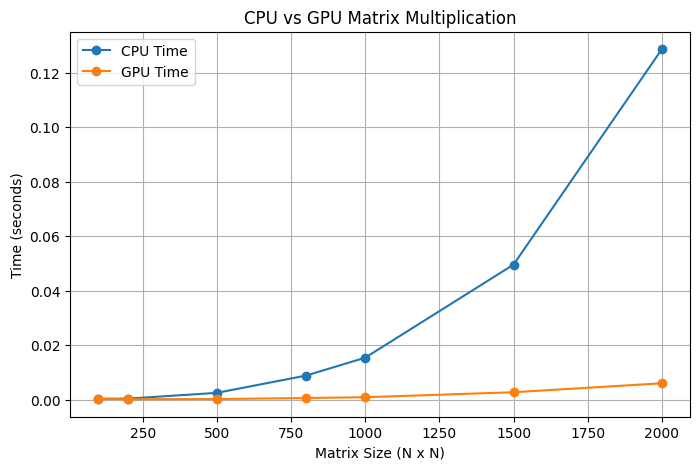

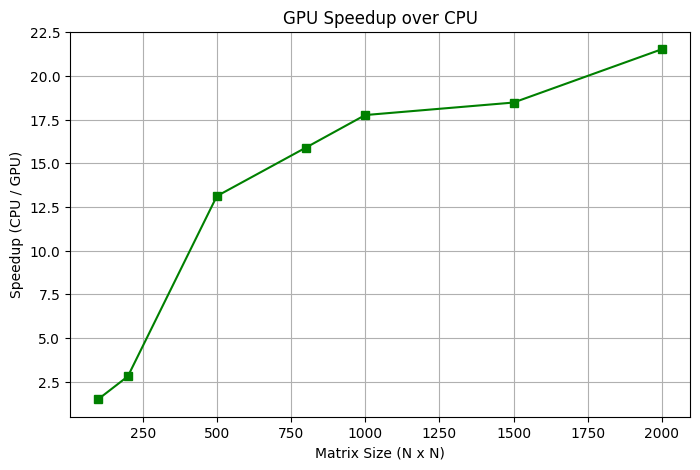

In [ ]:
import torch, time, matplotlib.pyplot as plt

sizes = [100, 200, 500, 800, 1000, 1500, 2000]
cpu_times, gpu_times, speedups = [], [], []

for N in sizes:
    a, b = torch.randn(N, N), torch.randn(N, N)

    # CPU
    start = time.time()
    torch.matmul(a, b)
    cpu_time = time.time() - start

    # GPU
    a_gpu, b_gpu = a.to('cuda'), b.to('cuda')
    torch.cuda.synchronize()
    start = time.time()
    torch.matmul(a_gpu, b_gpu)
    torch.cuda.synchronize()
    gpu_time = time.time() - start

    cpu_times.append(cpu_time)
    gpu_times.append(gpu_time)
    speedups.append(cpu_time / gpu_time)

# Plot CPU vs GPU times
plt.figure(figsize=(8,5))
plt.plot(sizes, cpu_times, 'o-', label='CPU Time')
plt.plot(sizes, gpu_times, 'o-', label='GPU Time')
plt.xlabel('Matrix Size (N x N)')
plt.ylabel('Time (seconds)')
plt.title('CPU vs GPU Matrix Multiplication')
plt.legend()
plt.grid(True)
plt.show()

# Plot speedup
plt.figure(figsize=(8,5))
plt.plot(sizes, speedups, 's-', color='green')
plt.xlabel('Matrix Size (N x N)')
plt.ylabel('Speedup (CPU / GPU)')
plt.title('GPU Speedup over CPU')
plt.grid(True)
plt.show()

## ⚡ Instruction-Level Parallelism (ILP) Demonstration

This experiment demonstrates the concept of **Instruction-Level Parallelism (ILP)** — a key performance enhancement strategy in modern processors.  
It compares **sequential execution** (no ILP) against **parallel instruction execution** (with ILP) using PyTorch tensor operations.

### 🔹 Experimental Setup
- Two random tensors `x` and `y` are created, each containing **10,000 elements**.  
- **Without ILP:** Each addition (`x[i] + y[i]`) is executed sequentially inside a Python loop.  
- **With ILP:** The same operation is performed using PyTorch’s vectorized tensor addition, which allows multiple additions to occur concurrently.

### 🔹 Conceptual Understanding
- In **non-ILP** (sequential) mode, the CPU executes **one instruction at a time**, waiting for each operation to complete before starting the next.  
- In **ILP**, the processor identifies **independent instructions** and executes them **simultaneously**, exploiting **hardware pipelines** and **parallel functional units**.

### 🔹 Key Insights
- ILP allows overlapping of instruction execution, reducing overall latency.  
- Vectorized operations in PyTorch simulate ILP by leveraging optimized CPU instruction pipelines (e.g., AVX).  
- Although Python itself is not parallel, underlying libraries like **PyTorch** utilize **low-level C++ and assembly optimizations** to achieve ILP-like speedups.  
- The resulting **speedup ratio** illustrates the efficiency gained through parallel instruction execution.


In [ ]:
import torch, time

# CPU tensors
x = torch.randn(10_000)
y = torch.randn(10_000)

# Without ILP (scalar loop)
start = time.time()
z = torch.zeros_like(x)
for i in range(len(x)):
    z[i] = x[i] + y[i]
t_no_ilp = time.time() - start

# With ILP (vectorized SIMD-like)
start = time.time()
z = x + y
t_ilp = time.time() - start

print(f"No ILP (loop): {t_no_ilp:.4f}s")
print(f"With ILP (vectorized): {t_ilp:.4f}s")
print(f"Speedup: {t_no_ilp / t_ilp:.2f}x")

No ILP (loop): 0.0939s
With ILP (vectorized): 0.0001s
Speedup: 1012.50x


## 🔁 CPU–GPU Data Transfer Overhead

This experiment explores the **data transfer latency** between the **CPU (host memory)** and the **GPU (device memory)** — an essential factor in GPU computing performance and architectural efficiency.

### 🔹 Experimental Setup
- A tensor `x_cpu` containing **10 million elements** is created on the CPU.  
- The tensor is then:
  1. **Transferred to the GPU** using `.to('cuda')`
  2. **Transferred back to the CPU** using `.to('cpu')`
- Transfer times for both directions are measured separately using Python’s `time` module.
- `torch.cuda.synchronize()` ensures accurate timing by waiting for GPU operations to complete.

### 🔹 Conceptual Understanding
- In GPU-based architectures, computation is often much faster on the GPU, but **data movement** between the CPU and GPU can become a bottleneck.  
- This transfer happens over the **PCI Express (PCIe) bus**, which has limited bandwidth compared to GPU memory bandwidth.  
- Therefore, minimizing host–device data transfers is crucial for achieving optimal GPU performance.

### 🔹 Key Insights
- CPU–GPU transfer overhead demonstrates the **memory hierarchy** and **communication latency** between processor units.  
- High transfer times relative to computation time reveal why **data locality** and **memory optimization** are vital in parallel computing.  
- This experiment provides a practical understanding of **architectural trade-offs** between computation and communication in heterogeneous systems.


In [ ]:
x_cpu = torch.randn(10000000)
start = time.time()
x_gpu = x_cpu.to('cuda')
torch.cuda.synchronize()
print("Transfer to GPU:", time.time() - start)

start = time.time()
x_cpu_back = x_gpu.to('cpu')
torch.cuda.synchronize()
print("Transfer back to CPU:", time.time() - start)

Transfer to GPU: 0.009013652801513672
Transfer back to CPU: 0.025435209274291992


## 🧩 SISD (Single Instruction, Single Data)

This example demonstrates the **SISD** architecture — the simplest execution model where **one instruction** operates on **one data element** at a time.

### 🔹 Key Points
- Represents **sequential execution** with **no parallelism**.  
- Typical of traditional **single-core CPUs**.  
- Operation: a single arithmetic instruction (`x + y`) on scalar data.  
- Used as a **baseline** to compare with parallel models (SIMD, MISD, MIMD).

In essence, **SISD** reflects purely **serial processing**, executing one task at a time.  


In [ ]:
import torch, time

# SISD: Single instruction, single data
x = torch.tensor([5.0])
y = torch.tensor([3.0])

start = time.time()
z = x + y  # One instruction on one data pair
end = time.time()

print("SISD Result:", z.item())
print("SISD Time:", end - start)

SISD Result: 8.0
SISD Time: 0.00017023086547851562


## ⚙️ SIMD (Single Instruction, Multiple Data)

This experiment demonstrates the **SIMD** architecture model, where a **single instruction** is executed **simultaneously** on **multiple data elements**.

### 🔹 Key Points
- One operation (e.g., addition) is applied **in parallel** across large data arrays.  
- Utilizes **vectorized execution** — multiple arithmetic units perform the same operation concurrently.  
- Commonly implemented in **GPUs** and **vector processors** (like SSE, AVX).  
- PyTorch leverages this via **CUDA cores** to execute parallel arithmetic efficiently.

### 🔹 Example
A single addition instruction (`x + y`) is applied to **1,000,000 elements** in parallel on the GPU.

### 🔹 Insight
- **Throughput increases** dramatically compared to SISD.  
- **Instruction stream** remains single, but **data streams** are multiple.  
- This models **data-level parallelism (DLP)** — the foundation of GPU acceleration.  


In [ ]:
# SIMD: Single instruction, multiple data
x = torch.randn(1000000, device='cuda')
y = torch.randn(1000000, device='cuda')

torch.cuda.synchronize()
start = time.time()

z = x + y  # One instruction applied to all elements in parallel
torch.cuda.synchronize()

end = time.time()
print("SIMD Result (sum):", z[:5])
print("SIMD Time:", end - start)

SIMD Result (sum): tensor([-1.1995,  0.3673,  0.1134,  3.8068,  1.3712], device='cuda:0')
SIMD Time: 0.0003108978271484375


## 🧮 MISD (Multiple Instruction, Single Data)

This section illustrates the **MISD** architecture, where **multiple instructions** operate on the **same data** simultaneously.

### 🔹 Key Points
- The same data element is processed by **different functional units**, each performing a **distinct operation**.  
- Demonstrates **instruction-level parallelism (ILP)** rather than data parallelism.  
- Rare in real-world hardware, but conceptually useful for modeling **fault-tolerant** or **redundant** systems (e.g., spaceflight control).

### 🔹 Example
A single input value `x` undergoes several operations concurrently:
- Addition  
- Multiplication  
- Trigonometric computation (`sin`)  

Each represents a **different instruction stream** applied to the **same data**.

### 🔹 Insight
- MISD improves **instruction throughput** rather than data throughput.  
- Highlights how architectures can exploit **parallel instruction execution** even when data is limited.  


In [ ]:
# MISD: Multiple instruction, single data
x = torch.tensor([2.0], device='cuda')

torch.cuda.synchronize()
start = time.time()

# Different operations on same data
y1 = x + 5       # Instruction 1
y2 = x * 5       # Instruction 2
y3 = torch.sin(x)  # Instruction 3
torch.cuda.synchronize()

end = time.time()
print("MISD Results:", y1.item(), y2.item(), y3.item())
print("MISD Time:", end - start)

MISD Results: 7.0 10.0 0.9092974662780762
MISD Time: 0.012406110763549805


In [ ]:
# MIMD: Multiple instruction, multiple data
stream1 = torch.cuda.Stream()
stream2 = torch.cuda.Stream()

x1 = torch.randn(1000000, device='cuda')
x2 = torch.randn(1000000, device='cuda')

start = time.time()
with torch.cuda.stream(stream1):
    y1 = x1 + 10        # Instruction 1
with torch.cuda.stream(stream2):
    y2 = x2 * 10        # Instruction 2

torch.cuda.synchronize()
end = time.time()

print("MIMD Sample Outputs:", y1[:3], y2[:3])
print("MIMD Time:", end - start)

MIMD Sample Outputs: tensor([ 9.0198,  7.7512, 10.2191], device='cuda:0') tensor([18.1364, 10.5333, -0.9091], device='cuda:0')
MIMD Time: 0.00119781494140625


# Exercise

### **Task 1:** Plot the time and speedup data(s) for ILP using atleast 5 set of values.
### **Task 2:** Plot the graphs of FLYN's Taxanomy techniques using some sample data.
### **Task 3:** Inspect the memory details in Pytorch Library.